# ARIMA-Tools: Development and Testing

**Miguel A. Arranz**  
**Applied Time Series Econometrics (ATSE)**

---

This notebook is used for the development, testing, and validation of the
`ARIMA-Tools` Python library.

The library provides teaching-oriented tools for empirical ARIMA modelling,
complementing functionality available in `statsmodels` and `statsforecast`.

## Development objectives

The main areas of development are:

- AR and MA root diagnostics
- Causality and invertibility
- Common and near-common roots
- Residual diagnostics
- Recursive estimation and parameter stability
- Model selection
- Static and multi-step forecasting
- Reconstruction of forecasts on the original scale

Forecast evaluation and model comparison will be handled separately by
`Forecast-Tools`.

---

**Status:** Under development

In [56]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd

from statsmodels.tsa.arima.model import ARIMA

import arima_tools as at

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Simulated ARMA(1,1) Proecess

In [57]:
from statsmodels.tsa.arima_process import ArmaProcess

np.random.seed(12345)

# y_t = 0.7 y_{t-1} + eps_t + 0.4 eps_{t-1}
ar = np.array([1, -0.7])
ma = np.array([1, 0.4])

process = ArmaProcess(ar, ma)
y = process.generate_sample(nsample=1000)

result = ARIMA(y, order=(1, 0, 1), trend="n").fit()

print(result.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -1398.570
Date:                Mon, 28 Sep 2026   AIC                           2803.140
Time:                        14:51:39   BIC                           2817.863
Sample:                             0   HQIC                          2808.735
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6815      0.028     24.324      0.000       0.627       0.736
ma.L1          0.4130      0.035     11.948      0.000       0.345       0.481
sigma2         0.9588      0.042     22.892      0.0

In [58]:
print("AR parameters:", result.arparams)
print("MA parameters:", result.maparams)

print("AR roots:", result.arroots)
print("MA roots:", result.maroots)

AR parameters: [0.68146324]
MA parameters: [0.41301678]
AR roots: [1.46743059]
MA roots: [-2.42120913]


In [59]:
roots = at.root_diagnostics(result)
roots

,Type,Root,Value,Modulus,Inverse Root,Inverse Modulus
0,AR,1,1.467431,1.467431,0.681463,0.681463
1,MA,1,-2.421209,2.421209,-0.413017,0.413017


In [60]:
print("Causal:", at.is_causal(result))
print("Invertible:", at.is_invertible(result))

Causal: True
Invertible: True


In [61]:
at.common_roots(result)

,AR Root,MA Root,AR Inverse Root,MA Inverse Root,Distance,Classification


In [62]:
at.common_roots(result, tol=2.0)

,AR Root,MA Root,AR Inverse Root,MA Inverse Root,Distance,Classification
0,1,1,0.681463,-0.413017,1.09448,Near-common


In [63]:
at.root_summary(result)

Causal AR component        True
Invertible MA component    True
Common root pairs             0
Near-common root pairs        0
Minimum AR-MA distance      NaN
Name: Root diagnostics, dtype: object

## Near-common roots

In [64]:
np.random.seed(2468)

# Near-cancelling ARMA(1,1):
# AR inverse root = 0.70
# MA inverse root = 0.68
ar_near = np.array([1, -0.70])
ma_near = np.array([1, -0.68])

process_near = ArmaProcess(ar_near, ma_near)
y_near = process_near.generate_sample(nsample=2000)

result_near = ARIMA(
    y_near,
    order=(1, 0, 1),
    trend="n"
).fit()

print("AR parameter:", result_near.arparams)
print("MA parameter:", result_near.maparams)

at.root_diagnostics(result_near)

AR parameter: [0.43039912]
MA parameter: [-0.40549696]


,Type,Root,Value,Modulus,Inverse Root,Inverse Modulus
0,AR,1,2.323425,2.323425,0.430399,0.430399
1,MA,1,2.466110,2.466110,0.405497,0.405497


In [65]:
at.common_roots(result_near, tol=0.05)

,AR Root,MA Root,AR Inverse Root,MA Inverse Root,Distance,Classification
0,1,1,0.430399,0.405497,0.024902,Near-common


In [66]:
at.root_summary(result_near)

Causal AR component            True
Invertible MA component        True
Common root pairs                 0
Near-common root pairs            1
Minimum AR-MA distance     0.024902
Name: Root diagnostics, dtype: object

## AR(2) Complex Roots

In [67]:
np.random.seed(1357)

# AR(2) with complex-conjugate roots
# y_t = 1.2 y_{t-1} - 0.5 y_{t-2} + eps_t
ar_complex = np.array([1, -1.2, 0.5])
ma_complex = np.array([1])

process_complex = ArmaProcess(ar_complex, ma_complex)
y_complex = process_complex.generate_sample(nsample=2000)

result_complex = ARIMA(
    y_complex,
    order=(2, 0, 0),
    trend="n"
).fit()

print("AR parameters:", result_complex.arparams)

at.root_diagnostics(result_complex)

AR parameters: [ 1.21813126 -0.50164691]


,Type,Root,Value,Modulus,Inverse Root,Inverse Modulus
0,AR,1,1.214132-0.720637j,1.41189,0.609066+0.361505j,0.70827
1,AR,2,1.214132+0.720637j,1.41189,0.609066-0.361505j,0.70827


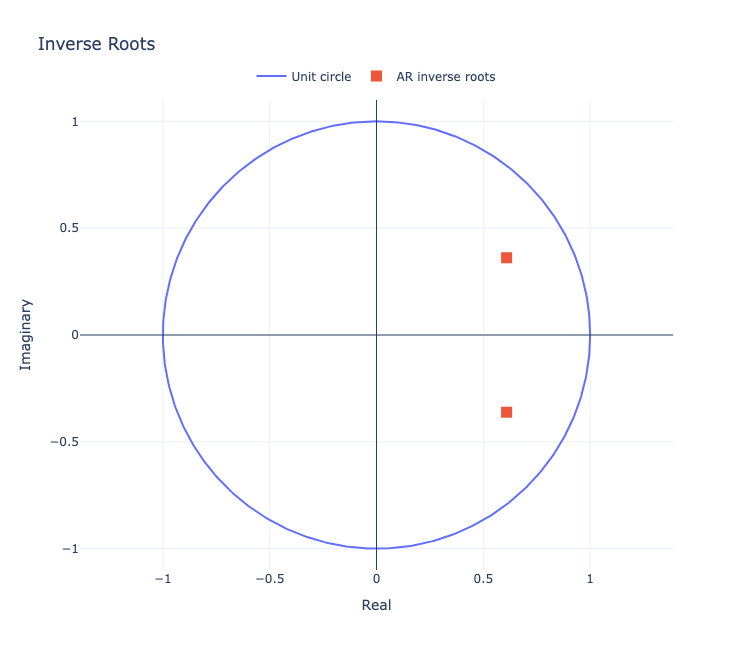

In [68]:
at.plot_inverse_roots(result_complex)

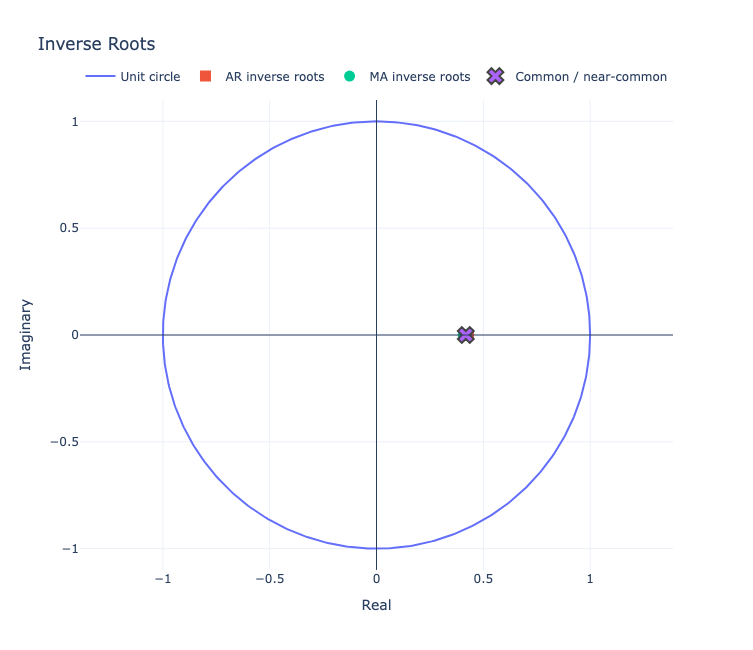

In [69]:
at.plot_inverse_roots(result_near)

In [70]:
at.root_summary(result_complex)

Causal AR component        True
Invertible MA component    True
Common root pairs             0
Near-common root pairs        0
Minimum AR-MA distance      NaN
Name: Root diagnostics, dtype: object